In [ ]:
import torch
import torch.nn as nn

In [ ]:
class RNNModel(nn.Module):
  def __init__(self):
    super(RNNModel, self).__init__()
    self.rnn = nn.RNN(input_size=5, hidden_size=3, batch_first=True)
    self.fc = nn.Linear(3,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):
    out, _ = self.rnn(x)
    out = out[:,-1,:]    # taking the last time step (final impression of all the inputs)
    out = self.fc(out)
    out = self.sigmoid(out)
    return out

In [ ]:
model = RNNModel()

In [ ]:
model

RNNModel(
  (rnn): RNN(5, 3, batch_first=True)
  (fc): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [ ]:
# count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(total_params)


34


In [ ]:
print(f"\nTrainable parameters breakdown:")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.numel()} params {list(param.shape)}")

print(f"\nTotal Trainable Parameters: {total_params}")


Trainable parameters breakdown:
  rnn.weight_ih_l0: 15 params [3, 5]
  rnn.weight_hh_l0: 9 params [3, 3]
  rnn.bias_ih_l0: 3 params [3]
  rnn.bias_hh_l0: 3 params [3]
  fc.weight: 3 params [1, 3]
  fc.bias: 1 params [1]

Total Trainable Parameters: 34


## Here we have calculated two bias for a same state. Because pyTorch counts it seperately for which in feedback the bias is calculated. So, it is 34 parameters. But the same network would have 31 parameters in tensorFlow. But letter we will declare a single bias for both which is combined bias and that will be used.




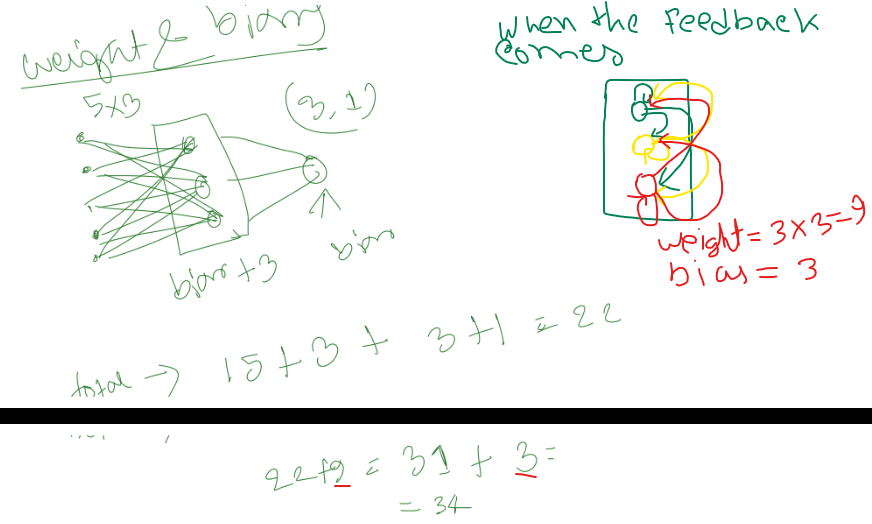

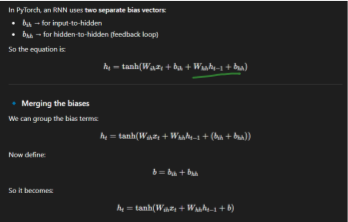